In [1]:
#Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name.lower() == 'notebooks' else cwd

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'outputs' / 'figures'
TABLES_DIR = PROJECT_ROOT / 'outputs' / 'tables'

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

model_path = PROCESSED_DIR / 'modelling_data.csv'

model_df = pd.read_csv(model_path)

model_df.head()

,settlement_date,settlement_period,from_uk_naive,forecast_gco2_per_kwh,actual_gco2_per_kwh,index,price_gbp_per_mwh
0,2026-06-22,1,2026-06-22 00:00:00,193,189,high,111.19
1,2026-06-22,2,2026-06-22 00:30:00,188,187,high,108.63
2,2026-06-22,3,2026-06-22 01:00:00,196,182,high,104.94
3,2026-06-22,4,2026-06-22 01:30:00,190,179,high,100.83
4,2026-06-22,5,2026-06-22 02:00:00,189,179,high,81.33


In [3]:
# Electrolyser Assumptions
ELECTROLYSER_CAPACITY_MW = 1.0
PERIOD_HRS = 0.5

HYDROGEN_TARGET_KG_PER_DAY = 300
ELECTROLYSER_KWH_PER_KG = 50

DAILY_ELECTRICITY_TARGET_MWH = (HYDROGEN_TARGET_KG_PER_DAY * ELECTROLYSER_KWH_PER_KG / 1000)

MAX_ENERGY_PER_PERIOD_MWH = ELECTROLYSER_CAPACITY_MW * PERIOD_HRS

In [4]:
def create_baseline_schedule(model_df):#In hindsight should have created with daily_electricity_KWH as variable so could use for sens analysis
    schedule = model_df.copy()

    periods_per_day = 24/PERIOD_HRS

    schedule['sched_energy_mwh'] = DAILY_ELECTRICITY_TARGET_MWH/periods_per_day
    schedule['sched_power_mw'] = schedule['sched_energy_mwh']/PERIOD_HRS
    schedule['sched_name'] = 'Baseline even op'
    
    return schedule

In [5]:
baseline_schedule = create_baseline_schedule(model_df)

baseline_schedule[[
    "settlement_date",
    "settlement_period",
    "sched_power_mw",
    "sched_energy_mwh"
]].head()

,settlement_date,settlement_period,sched_power_mw,sched_energy_mwh
0,2026-06-22,1,0.625,0.3125
1,2026-06-22,2,0.625,0.3125
2,2026-06-22,3,0.625,0.3125
3,2026-06-22,4,0.625,0.3125
4,2026-06-22,5,0.625,0.3125


In [6]:
#Simple optimiser this assumes can switch electrolyser on and off easily will make more complicated later
def optimise_daily_sched(model_df, signal_col, sched):
    schedule = model_df.copy()

    schedule['sched_energy_mwh']=0.0
    schedule['sched_power_mw']=0.0
    schedule['sched_name']=sched

    for date, day_df in schedule.groupby('settlement_date'):
        remaining_energy = DAILY_ELECTRICITY_TARGET_MWH

        ordered_indics = day_df.sort_values(signal_col).index

        for idx in ordered_indics:
            if remaining_energy <=1e-9:
                break

            energy_this_period = min(MAX_ENERGY_PER_PERIOD_MWH, remaining_energy)
            schedule.loc[idx, "sched_energy_mwh"] = energy_this_period
            schedule.loc[idx, "sched_power_mw"] = energy_this_period / PERIOD_HRS
            
            remaining_energy -= energy_this_period
        
        if remaining_energy > 1e-6:
            print(f"Warning: unmet energy target on {date}: {remaining_energy:.3f} MWh")
    
    return schedule

In [7]:
cost_min_schedule = optimise_daily_sched(
    model_df,
    signal_col = 'price_gbp_per_mwh',
    sched = 'Cost min'
)

forecast_carbon_min_schedule = optimise_daily_sched(
    model_df,
    signal_col = 'forecast_gco2_per_kwh',
    sched = 'Forecast carbon min'
)

#Actual carbon min schedule is a perfect hindsight benchmark
actual_carbon_min_schedule = optimise_daily_sched(
    model_df,
    signal_col='actual_gco2_per_kwh',
    sched = 'Actual carbon min'
)

In [8]:
CARBON_VALUE_GBP_PER_TCO2 = 264

model_df["balanced_signal_gbp_per_mwh"] = (
    model_df["price_gbp_per_mwh"]
    + CARBON_VALUE_GBP_PER_TCO2 * (model_df["forecast_gco2_per_kwh"] / 1000)
)

balanced_schedule = optimise_daily_sched(
    model_df,
    signal_col="balanced_signal_gbp_per_mwh",
    sched="Balanced cost-carbon"
)

In [9]:
def evaluate_schedule(schedule):#Evaluate the schedule 
    energy_mwh = schedule['sched_energy_mwh'].sum()

    electricity_cost_gbp = (
        schedule['sched_energy_mwh'] * schedule['price_gbp_per_mwh']
    ).sum()
    
    actual_emissions_kgco2 = (
        schedule['sched_energy_mwh'] * schedule['actual_gco2_per_kwh']
    ).sum()
    
    forecast_emissions_kgco2 = (
        schedule['sched_energy_mwh'] * schedule['forecast_gco2_per_kwh']
    ).sum()
    
    hydrogen_kg = energy_mwh * 1000 / ELECTROLYSER_KWH_PER_KG
    
    avg_price_paid = electricity_cost_gbp / energy_mwh
    weighted_actual_carbon = actual_emissions_kgco2 / energy_mwh
    weighted_forecast_carbon = forecast_emissions_kgco2 / energy_mwh
    
    return pd.Series({
        "sched_name": schedule["sched_name"].iloc[0],
        "electricity_used_mwh": energy_mwh,
        "hydrogen_produced_kg": hydrogen_kg,
        "electricity_cost_gbp": electricity_cost_gbp,
        "actual_emissions_kgco2": actual_emissions_kgco2,
        "actual_emissions_tco2": actual_emissions_kgco2 / 1000,
        "forecast_emissions_kgco2": forecast_emissions_kgco2,
        "avg_price_paid_gbp_per_mwh": avg_price_paid,
        "weighted_actual_carbon_gco2_per_kwh": weighted_actual_carbon,
        "weighted_forecast_carbon_gco2_per_kwh": weighted_forecast_carbon
    })

In [10]:
results = pd.DataFrame([
    evaluate_schedule(baseline_schedule),
    evaluate_schedule(cost_min_schedule),
    evaluate_schedule(forecast_carbon_min_schedule),
    evaluate_schedule(actual_carbon_min_schedule),
    evaluate_schedule(balanced_schedule)
])

baseline_cost = results.loc[
    results['sched_name'] == 'Baseline even op',
    'electricity_cost_gbp'
].iloc[0]

baseline_emissions = results.loc[
    results['sched_name'] == 'Baseline even op',
    'actual_emissions_kgco2'
].iloc[0]

results['cost_saving_vs_baseline_pct'] = (
    (baseline_cost - results['electricity_cost_gbp']) / baseline_cost * 100
)

results['actual_emissions_saving_vs_baseline_pct'] = (
    (baseline_emissions - results['actual_emissions_kgco2']) / baseline_emissions * 100
)

results

,sched_name,electricity_used_mwh,hydrogen_produced_kg,electricity_cost_gbp,actual_emissions_kgco2,actual_emissions_tco2,forecast_emissions_kgco2,avg_price_paid_gbp_per_mwh,weighted_actual_carbon_gco2_per_kwh,weighted_forecast_carbon_gco2_per_kwh,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,Baseline even op,105.0,2100.0,11546.109253,16614.0625,16.614062,16465.0,109.962945,158.229167,156.809524,0.000000,0.000000
1,Cost min,105.0,2100.0,7382.428065,15408.0000,15.408000,15438.0,70.308839,146.742857,147.028571,36.061335,7.259287
2,Forecast carbon min,105.0,2100.0,10047.944815,13932.5000,13.932500,13475.5,95.694713,132.690476,128.338095,12.975492,16.140318
3,Actual carbon min,105.0,2100.0,9000.190033,13731.5000,13.731500,13603.5,85.716096,130.776190,129.557143,22.050018,17.350136
4,Balanced cost-carbon,105.0,2100.0,7479.892858,14701.5000,14.701500,14687.5,71.237075,140.014286,139.880952,35.217200,11.511709


In [11]:
results_path = TABLES_DIR / 'schedule_comparison_restults.csv'
results.to_csv(results_path, index=False)

print('Saved:', results_path)

Saved: C:\Users\iniob\Toni_projects\Hydrogen Project\outputs\tables\schedule_comparison_restults.csv


In [12]:
example_date = model_df["settlement_date"].min()
example_date

'2026-06-22'

In [13]:
plot_df = pd.concat([
    baseline_schedule,
    cost_min_schedule,
    forecast_carbon_min_schedule,
    balanced_schedule
])

plot_day = plot_df[plot_df["settlement_date"] == example_date].copy()

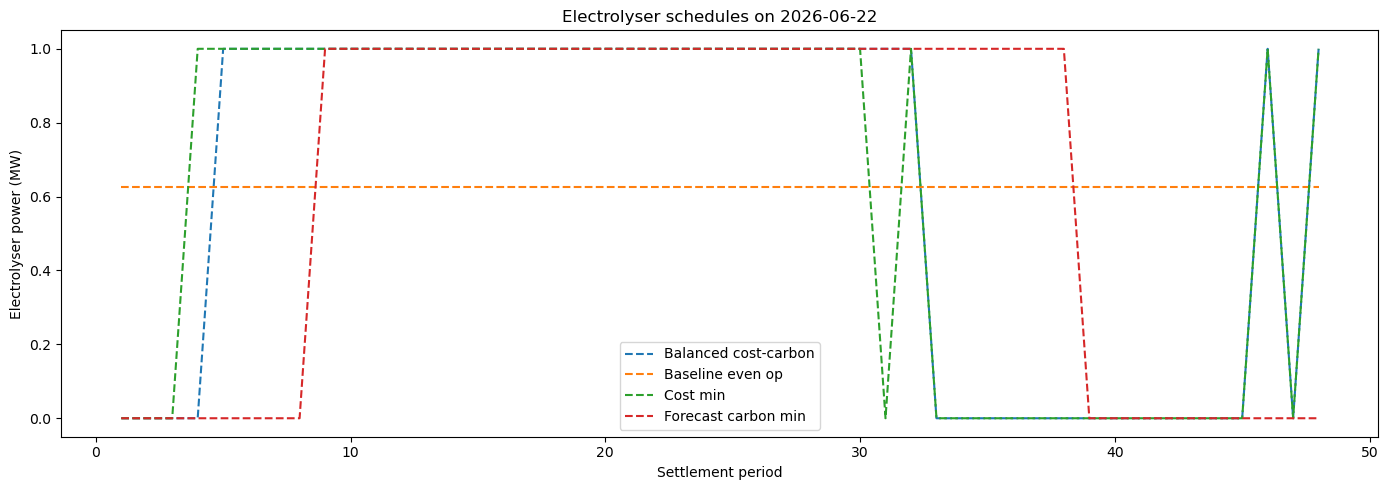

In [14]:
fig, ax = plt.subplots(figsize=(14, 5)) #Plot the schedules against the settlement period on the first day

for sched_name, group in plot_day.groupby("sched_name"):
    ax.plot(
        group["settlement_period"],
        group["sched_power_mw"],
        label=sched_name,
        linewidth=1.5,
        linestyle= '--'
    )

ax.set_xlabel("Settlement period")
ax.set_ylabel("Electrolyser power (MW)")
ax.set_title(f"Electrolyser schedules on {example_date}")
ax.legend()

fig.tight_layout()
plt.savefig(FIGURES_DIR / "example_day_schedule_comparison.png", dpi=300)
plt.show()

In [15]:
plot_df = pd.concat([
    baseline_schedule,
    cost_min_schedule,
    forecast_carbon_min_schedule,
    actual_carbon_min_schedule,
    balanced_schedule
]).copy()

plot_df["settlement_date"] = pd.to_datetime(plot_df["settlement_date"])

plot_df["timestamp"] = (
    plot_df["settlement_date"]
    + pd.to_timedelta((plot_df["settlement_period"] - 1) * 30, unit="m")
)

plot_df = plot_df.sort_values(["sched_name", "timestamp"])

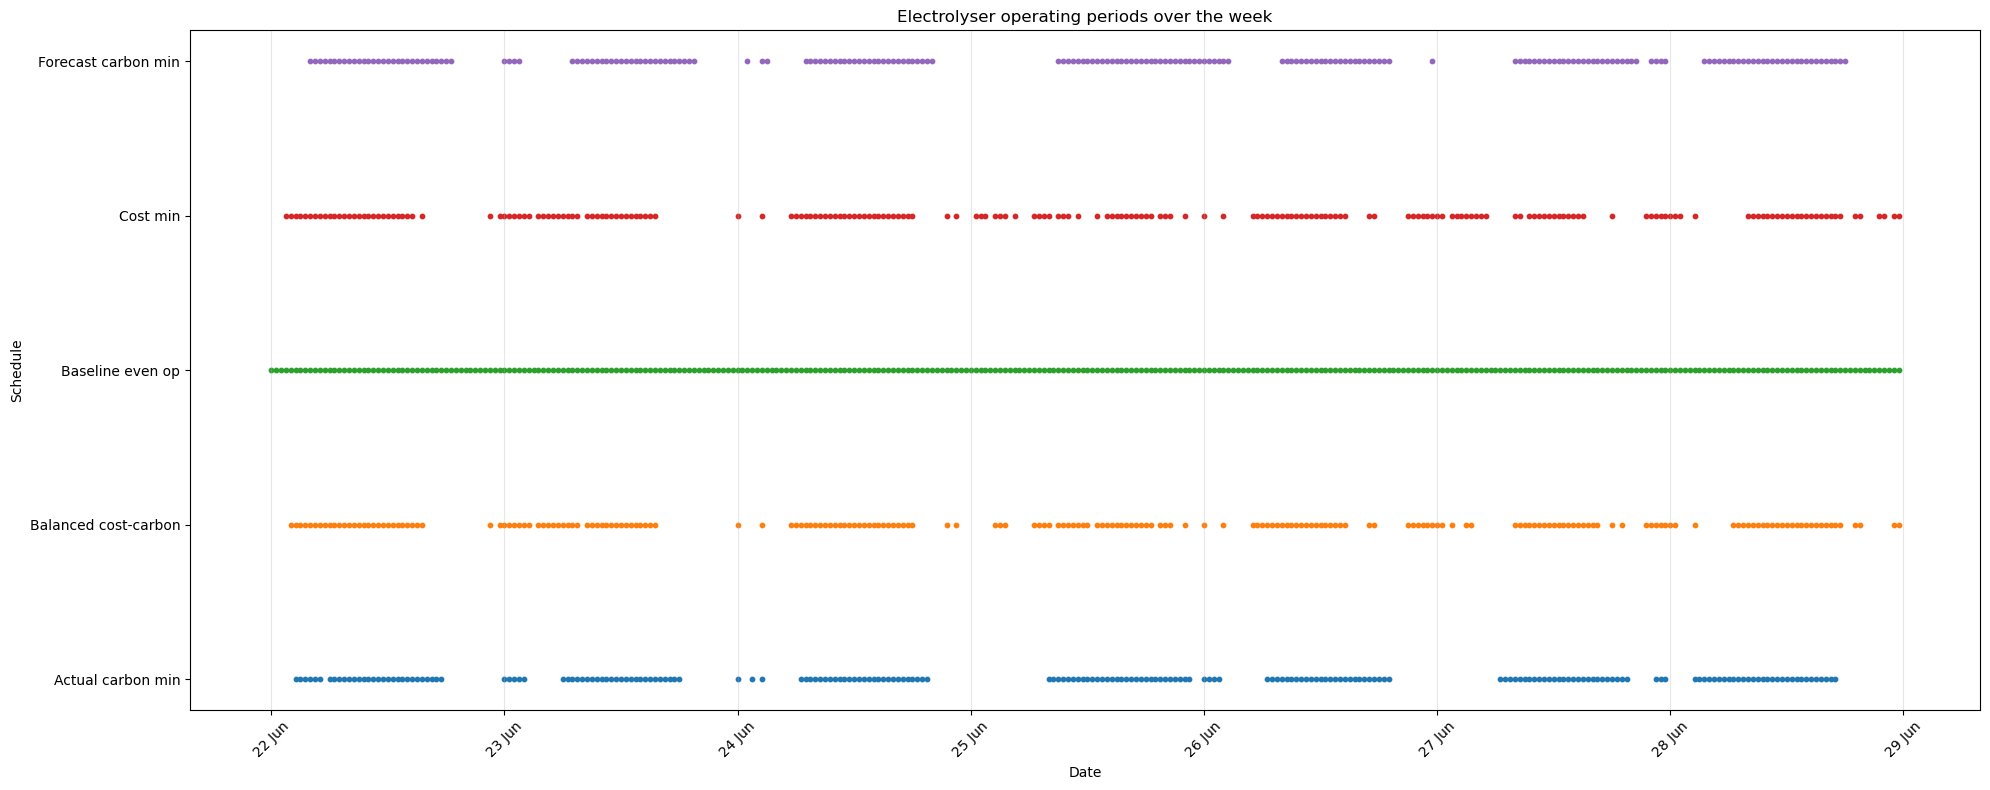

In [16]:
import matplotlib.dates as mdates

on_df = plot_df[plot_df["sched_power_mw"] > 0].copy()

fig, ax = plt.subplots(figsize=(20,8))

for sched_name, group in on_df.groupby("sched_name"):
    ax.scatter(
        group["timestamp"],
        [sched_name] * len(group),
        s=10,
        label=sched_name
    )

ax.set_xlabel("Date")
ax.set_ylabel("Schedule")
ax.set_title("Electrolyser operating periods over the week")

ax.xaxis.set_major_locator(mdates.DayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.tick_params(axis="x", rotation=45)

ax.grid(True, axis="x", alpha=0.3)

fig.tight_layout()
plt.savefig(FIGURES_DIR / 'week_schedule_comparison.png', dpi=300)

In [17]:
results_rounded = results.copy()

numeric_cols = results_rounded.select_dtypes(include="number").columns
results_rounded[numeric_cols] = results_rounded[numeric_cols].round(2)

results_rounded[
    [
        "sched_name",
        "electricity_used_mwh",
        "hydrogen_produced_kg",
        "electricity_cost_gbp",
        "actual_emissions_tco2",
        "avg_price_paid_gbp_per_mwh",
        "weighted_actual_carbon_gco2_per_kwh",
        "cost_saving_vs_baseline_pct",
        "actual_emissions_saving_vs_baseline_pct"
    ]
]

,sched_name,electricity_used_mwh,hydrogen_produced_kg,electricity_cost_gbp,actual_emissions_tco2,avg_price_paid_gbp_per_mwh,weighted_actual_carbon_gco2_per_kwh,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,Baseline even op,105.0,2100.0,11546.11,16.61,109.96,158.23,0.00,0.00
1,Cost min,105.0,2100.0,7382.43,15.41,70.31,146.74,36.06,7.26
2,Forecast carbon min,105.0,2100.0,10047.94,13.93,95.69,132.69,12.98,16.14
3,Actual carbon min,105.0,2100.0,9000.19,13.73,85.72,130.78,22.05,17.35
4,Balanced cost-carbon,105.0,2100.0,7479.89,14.70,71.24,140.01,35.22,11.51


In [18]:
#Rank schedules against each other for electricity cost as well as emissions based on savings compared to baseline
cost_ranking = results.sort_values("electricity_cost_gbp")[
    ["sched_name", "electricity_cost_gbp", "cost_saving_vs_baseline_pct"]
]

emissions_ranking = results.sort_values("actual_emissions_kgco2")[
    ["sched_name", "actual_emissions_tco2", "actual_emissions_saving_vs_baseline_pct"]
]

cost_ranking, emissions_ranking

(             sched_name  electricity_cost_gbp  cost_saving_vs_baseline_pct
 1              Cost min           7382.428065                    36.061335
 4  Balanced cost-carbon           7479.892858                    35.217200
 3     Actual carbon min           9000.190033                    22.050018
 2   Forecast carbon min          10047.944815                    12.975492
 0      Baseline even op          11546.109253                     0.000000,
              sched_name  actual_emissions_tco2  \
 3     Actual carbon min              13.731500   
 2   Forecast carbon min              13.932500   
 4  Balanced cost-carbon              14.701500   
 1              Cost min              15.408000   
 0      Baseline even op              16.614062   
 
    actual_emissions_saving_vs_baseline_pct  
 3                                17.350136  
 2                                16.140318  
 4                                11.511709  
 1                                 7.259287  
 0   

In [19]:
forecast_carbon_emissions = results.loc[
    results["sched_name"] == "Forecast carbon min",
    "actual_emissions_kgco2"
].iloc[0]

actual_carbon_emissions = results.loc[
    results["sched_name"] == "Actual carbon min",
    "actual_emissions_kgco2"
].iloc[0]

baseline_emissions = results.loc[
    results["sched_name"] == "Baseline even op",
    "actual_emissions_kgco2"
].iloc[0]

forecast_gap_kgco2 = forecast_carbon_emissions - actual_carbon_emissions
forecast_saving_kgco2 = baseline_emissions - forecast_carbon_emissions
forecast_capture_pct = (
    (baseline_emissions - forecast_carbon_emissions)
    / (baseline_emissions - actual_carbon_emissions)
    * 100
)

print("Forecast-carbon extra emissions vs hindsight:", round(forecast_gap_kgco2, 2), "kgCO2")
print("Share of maximum possible emissions saving captured:", round(forecast_capture_pct, 2), "%")

forecast_vs_hindsight = pd.DataFrame([{
    'extra_emissions_vs_hindsight_kgco2': forecast_gap_kgco2,
    'forecast_gap_kgco2': forecast_gap_kgco2,
    'forecast_saving_kgco2': forecast_saving_kgco2,
    'forecast_capture_pct': forecast_capture_pct
}])

forecast_vs_hindsight.to_csv(
    TABLES_DIR / 'forecast_vs_hindsight_summary.csv',
    index=False
)

Forecast-carbon extra emissions vs hindsight: 201.0 kgCO2
Share of maximum possible emissions saving captured: 93.03 %


## Sensitivity Analysis

### Carbon Value Sensitivity



In [20]:
carbon_values = [132,264,396]

def carbon_sensitivity(carbon_value, model_df):

    sens_model = model_df.copy()
    sens_model['balanced_signal_gbp_per_mwh_sens'] =sens_model["forecast_gco2_per_kwh"]/1000*carbon_value+sens_model['price_gbp_per_mwh']
    schedule = optimise_daily_sched(
        sens_model,
        signal_col = 'balanced_signal_gbp_per_mwh_sens',
        sched = f'Balanced £{carbon_value}/tCO2'
    )

    evaluated = evaluate_schedule(schedule)
    evaluated['carbon_value_gbp_per_tco2'] = carbon_value

    return evaluated

In [21]:
carbon_value_results = pd.DataFrame([
    carbon_sensitivity(value, model_df) for value in carbon_values])

carbon_value_results["cost_saving_vs_baseline_pct"] = (
    (baseline_cost - carbon_value_results["electricity_cost_gbp"])
    / baseline_cost * 100
)

carbon_value_results["actual_emissions_saving_vs_baseline_pct"] = (
    (baseline_emissions - carbon_value_results["actual_emissions_kgco2"])
    / baseline_emissions * 100
)

carbon_value_results[[
    "carbon_value_gbp_per_tco2",
    "electricity_cost_gbp",
    "actual_emissions_tco2",
    "cost_saving_vs_baseline_pct",
    "actual_emissions_saving_vs_baseline_pct"
]].round(2)

,carbon_value_gbp_per_tco2,electricity_cost_gbp,actual_emissions_tco2,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,132,7419.91,15.08,35.74,9.22
1,264,7479.89,14.70,35.22,11.51
2,396,7535.88,14.56,34.73,12.35


In [22]:
carbon_value_results.to_csv(
    TABLES_DIR / 'carbon_value_sensitivity_results.csv',
    index=False
)



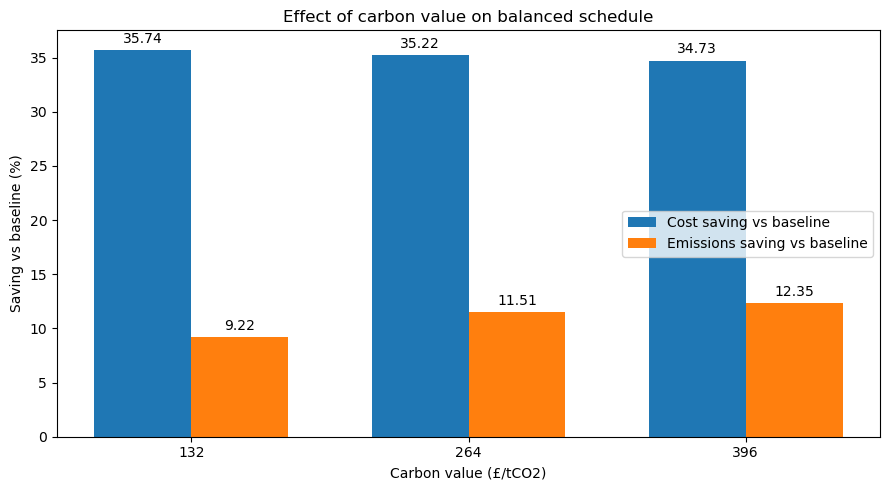

In [23]:
x = np.arange(len(carbon_value_results))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2,
    carbon_value_results["cost_saving_vs_baseline_pct"],
    width,
    label="Cost saving vs baseline"
)

bars2 = ax.bar(
    x + width/2,
    carbon_value_results["actual_emissions_saving_vs_baseline_pct"],
    width,
    label="Emissions saving vs baseline"
)

ax.set_xticks(x)
ax.set_xticklabels(carbon_value_results["carbon_value_gbp_per_tco2"].astype(str))

ax.set_xlabel("Carbon value (£/tCO2)")
ax.set_ylabel("Saving vs baseline (%)")
ax.set_title("Effect of carbon value on balanced schedule")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom"
        )

fig.tight_layout()
plt.savefig(FIGURES_DIR / "carbon_value_sensitivity_grouped_bar.png", dpi=300)
plt.show()

## Efficiency Sensitivity

In [24]:
def baseline_sched_target(df, daily_target_mwh):
    sched = df.copy()

    periods_per_day = sched.groupby('settlement_date')['settlement_period'].transform('count')

    sched['sched_energy_mwh'] = daily_target_mwh / periods_per_day
    sched['sched_power_mw'] = sched['sched_energy_mwh'] / PERIOD_HRS

    if (sched['sched_power_mw'] > ELECTROLYSER_CAPACITY_MW).any():
        raise ValueError('Baseline schedule exceeds electrolyser capacity.')

    sched['sched_name'] = 'Baseline'

    return sched

In [25]:
def optimise_sched_target(df, signal_col, sched_name, daily_target_mwh):
    sched = df.copy()

    sched['sched_energy_mwh'] = 0.0
    sched['sched_power_mw'] = 0.0
    sched['sched_name'] = sched_name

    for date, day_df in sched.groupby('settlement_date'):
        remaining_energy = daily_target_mwh

        ordered_indices = day_df.sort_values(signal_col).index

        for idx in ordered_indices:
            if remaining_energy <= 1e-9:
                break

            energy_this_period = min(MAX_ENERGY_PER_PERIOD_MWH, remaining_energy)

            sched.loc[idx, 'sched_energy_mwh'] = energy_this_period
            sched.loc[idx, 'sched_power_mw'] = energy_this_period / PERIOD_HRS

            remaining_energy -= energy_this_period

        if remaining_energy > 1e-6:
            print(f'Warning: unmet energy target on {date}: {remaining_energy:.3f} MWh')

    return sched

In [26]:
def eval_sched_eff(sched, kwh_per_kg):
    energy_mwh = sched['sched_energy_mwh'].sum()

    electricity_cost_gbp = (
        sched['sched_energy_mwh'] * sched['price_gbp_per_mwh']
    ).sum()

    actual_emissions_kgco2 = (
        sched['sched_energy_mwh'] * sched['actual_gco2_per_kwh']
    ).sum()

    forecast_emissions_kgco2 = (
        sched['sched_energy_mwh'] * sched['forecast_gco2_per_kwh']
    ).sum()

    hydrogen_kg = energy_mwh * 1000 / kwh_per_kg

    return pd.Series({
        'sched_name': sched['sched_name'].iloc[0],
        'electrolyser_kwh_per_kg': kwh_per_kg,
        'electricity_used_mwh': energy_mwh,
        'hydrogen_produced_kg': hydrogen_kg,
        'electricity_cost_gbp': electricity_cost_gbp,
        'actual_emissions_kgco2': actual_emissions_kgco2,
        'actual_emissions_tco2': actual_emissions_kgco2 / 1000,
        'forecast_emissions_kgco2': forecast_emissions_kgco2,
        'avg_price_paid_gbp_per_mwh': electricity_cost_gbp / energy_mwh,
        'weighted_actual_carbon_gco2_per_kwh': actual_emissions_kgco2 / energy_mwh
    })

In [27]:
eff_values = [45, 50, 55]
central_carbon_value = 264

eff_results = []

eff_results_list = []

for kwh_per_kg in eff_values:
    daily_target_mwh = HYDROGEN_TARGET_KG_PER_DAY * kwh_per_kg / 1000

    print('\nEfficiency:', kwh_per_kg, 'kWh/kg')
    print('Daily target:', daily_target_mwh, 'MWh')

    temp_df = model_df.copy()

    temp_df['balanced_signal_gbp_per_mwh'] = (
        temp_df['price_gbp_per_mwh']
        + central_carbon_value * (temp_df['forecast_gco2_per_kwh'] / 1000)
    )

    baseline_sched = baseline_sched_target(
        temp_df,
        daily_target_mwh=daily_target_mwh
    )

    cost_sched = optimise_sched_target(
        temp_df,
        signal_col='price_gbp_per_mwh',
        sched_name='Cost-min',
        daily_target_mwh=daily_target_mwh
    )

    forecast_carbon_sched = optimise_sched_target(
        temp_df,
        signal_col='forecast_gco2_per_kwh',
        sched_name='Forecast-carbon',
        daily_target_mwh=daily_target_mwh
    )

    balanced_sched = optimise_sched_target(
        temp_df,
        signal_col='balanced_signal_gbp_per_mwh',
        sched_name='Balanced',
        daily_target_mwh=daily_target_mwh
    )

    scheds = [
        baseline_sched,
        cost_sched,
        forecast_carbon_sched,
        balanced_sched
    ]

    for sched in scheds:
        print(
            sched['sched_name'].iloc[0],
            'total energy:',
            round(sched['sched_energy_mwh'].sum(), 3),
            'max power:',
            round(sched['sched_power_mw'].max(), 3)
        )

        daily_energy = sched.groupby('settlement_date')['sched_energy_mwh'].sum()

        if not np.allclose(daily_energy.values, daily_target_mwh):
            print('Daily energy problem:')
            print(daily_energy)

        assert sched['sched_energy_mwh'].sum() > 0, (
            f"{sched['sched_name'].iloc[0]} has zero energy"
        )

    scenario_results = pd.DataFrame([
        eval_sched_eff(baseline_sched, kwh_per_kg),
        eval_sched_eff(cost_sched, kwh_per_kg),
        eval_sched_eff(forecast_carbon_sched, kwh_per_kg),
        eval_sched_eff(balanced_sched, kwh_per_kg)
    ])

    baseline_cost_eff = scenario_results.loc[
        scenario_results['sched_name'] == 'Baseline',
        'electricity_cost_gbp'
    ].iloc[0]

    baseline_emissions_eff = scenario_results.loc[
        scenario_results['sched_name'] == 'Baseline',
        'actual_emissions_kgco2'
    ].iloc[0]

    scenario_results['cost_saving_vs_baseline_pct'] = (
        (baseline_cost_eff - scenario_results['electricity_cost_gbp'])
        / baseline_cost_eff * 100
    )

    scenario_results['actual_emissions_saving_vs_baseline_pct'] = (
        (baseline_emissions_eff - scenario_results['actual_emissions_kgco2'])
        / baseline_emissions_eff * 100
    )

    eff_results_list.append(scenario_results)

eff_results = pd.concat(eff_results_list, ignore_index=True)


Efficiency: 45 kWh/kg
Daily target: 13.5 MWh
Baseline total energy: 94.5 max power: 0.562
Cost-min total energy: 94.5 max power: 1.0
Forecast-carbon total energy: 94.5 max power: 1.0
Balanced total energy: 94.5 max power: 1.0

Efficiency: 50 kWh/kg
Daily target: 15.0 MWh
Baseline total energy: 105.0 max power: 0.625
Cost-min total energy: 105.0 max power: 1.0
Forecast-carbon total energy: 105.0 max power: 1.0
Balanced total energy: 105.0 max power: 1.0

Efficiency: 55 kWh/kg
Daily target: 16.5 MWh
Baseline total energy: 115.5 max power: 0.688
Cost-min total energy: 115.5 max power: 1.0
Forecast-carbon total energy: 115.5 max power: 1.0
Balanced total energy: 115.5 max power: 1.0


In [28]:
eff_results_display = eff_results[[
    'electrolyser_kwh_per_kg',
    'sched_name',
    'electricity_used_mwh',
    'hydrogen_produced_kg',
    'electricity_cost_gbp',
    'actual_emissions_tco2',
    'cost_saving_vs_baseline_pct',
    'actual_emissions_saving_vs_baseline_pct'
]].round(2)

eff_results_display

,electrolyser_kwh_per_kg,sched_name,electricity_used_mwh,hydrogen_produced_kg,electricity_cost_gbp,actual_emissions_tco2,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,45,Baseline,94.5,2100.0,10391.50,14.95,0.00,0.00
1,45,Cost-min,94.5,2100.0,6233.24,13.56,40.02,9.30
2,45,Forecast-carbon,94.5,2100.0,8560.23,12.01,17.62,19.65
3,45,Balanced,94.5,2100.0,6324.29,12.92,39.14,13.61
4,50,Baseline,105.0,2100.0,11546.11,16.61,0.00,0.00
5,50,Cost-min,105.0,2100.0,7382.43,15.41,36.06,7.26
6,50,Forecast-carbon,105.0,2100.0,10047.94,13.93,12.98,16.14
7,50,Balanced,105.0,2100.0,7479.89,14.70,35.22,11.51
8,55,Baseline,115.5,2100.0,12700.72,18.28,0.00,0.00
9,55,Cost-min,115.5,2100.0,8628.95,17.15,32.06,6.16


In [29]:
eff_results.to_csv(
    TABLES_DIR / 'efficiency_sensitivity_results.csv',
    index=False
)

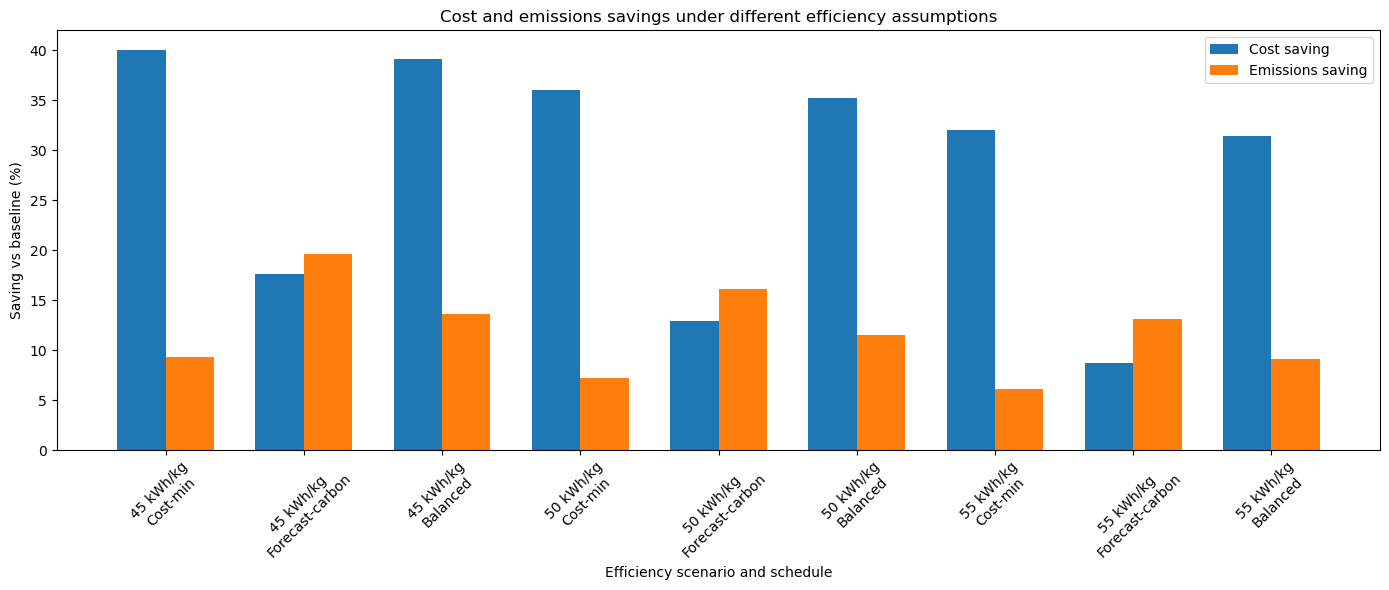

In [30]:
eff_plot_df = eff_results[
    eff_results['sched_name'] != 'Baseline'
].copy()

eff_plot_df['scenario'] = (
    eff_plot_df['electrolyser_kwh_per_kg'].astype(str)
    + ' kWh/kg\n'
    + eff_plot_df['sched_name']
)

x = np.arange(len(eff_plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))

cost_bars = ax.bar(
    x - width / 2,
    eff_plot_df['cost_saving_vs_baseline_pct'],
    width,
    label='Cost saving'
)

emissions_bars = ax.bar(
    x + width / 2,
    eff_plot_df['actual_emissions_saving_vs_baseline_pct'],
    width,
    label='Emissions saving'
)

ax.set_xticks(x)
ax.set_xticklabels(eff_plot_df['scenario'])

ax.set_xlabel('Efficiency scenario and schedule')
ax.set_ylabel('Saving vs baseline (%)')
ax.set_title('Cost and emissions savings under different efficiency assumptions')
ax.legend()

ax.tick_params(axis='x', rotation=45)

fig.tight_layout()
plt.savefig(FIGURES_DIR / 'efficiency_sensitivity_grouped_savings.png', dpi=300)
plt.show()

## Pulp constrained operation

BAse selects best half-hour periods, this will test how much value is lost when cannot switch on and off freely.
Using a max 3 starts per day and a minimum load when on of 0.2MW, prevent it being on at 0 MW etc or incredibly low, first time using Pulp added more comments for my own convenience.

In [31]:
import pulp

from pulp import (
    LpProblem,
    LpMinimize,
    LpVariable,
    lpSum,
    LpStatus,
    PULP_CBC_CMD,
    value
)

print(pulp.__version__)

3.3.2


In [32]:
def optimise_sched_pulp(
    df,
    signal_col,
    sched_name,
    max_starts_per_day=3,
    min_load_mw=0.2
):
    sched = df.copy()

    # These columns will store the optimisation result for each half-hour period.
    sched['sched_energy_mwh'] = 0.0
    sched['sched_power_mw'] = 0.0
    sched['sched_name'] = sched_name

    # Minimum energy used in one half-hour period if the electrolyser is switched on.
    # Example: 0.2 MW × 0.5 hour = 0.1 MWh.
    min_energy_when_on_mwh = min_load_mw * PERIOD_HRS

    # Optimise each day separately so that the electrolyser meets the daily H2 target.
    for date, day_df in sched.groupby('settlement_date'):
        day_df = day_df.sort_values('settlement_period')
        indices = day_df.index.tolist()
        periods = range(len(indices))

        # Safe label for the optimisation problem name.
        date_label = pd.to_datetime(date).strftime('%Y%m%d')

        # Create a minimisation problem.
        # The model will minimise the chosen signal, e.g. price, carbon, or balanced signal.
        problem = LpProblem(f'{sched_name}_{date_label}', LpMinimize)

        # Decision variable 1:
        # energy[t] = how much electricity the electrolyser uses in period t.
        # It can range from 0 to the maximum possible half-hour energy.
        energy = {
            t: LpVariable(
                f'energy_{date_label}_{t}',
                lowBound=0,
                upBound=MAX_ENERGY_PER_PERIOD_MWH
            )
            for t in periods
        }

        # Decision variable 2:
        # on[t] = 1 if the electrolyser is on in period t, otherwise 0.
        # This is binary because the electrolyser is either on or off.
        on = {
            t: LpVariable(
                f'on_{date_label}_{t}',
                cat='Binary'
            )
            for t in periods
        }

        # Decision variable 3:
        # start[t] = 1 if the electrolyser starts operating in period t.
        # This allows us to limit the number of starts per day.
        start = {
            t: LpVariable(
                f'start_{date_label}_{t}',
                cat='Binary'
            )
            for t in periods
        }

        # Objective:
        # Choose electricity use in each period to minimise the selected signal.
        # If signal_col is price, this minimises cost.
        # If signal_col is forecast carbon, this minimises forecast emissions.
        # If signal_col is balanced signal, this minimises price plus carbon value.
        problem += lpSum(
            energy[t] * day_df.loc[indices[t], signal_col]
            for t in periods
        )

        # Constraint 1:
        # Total electricity used across the day must equal the daily production target.
        problem += lpSum(
            energy[t] for t in periods
        ) == DAILY_ELECTRICITY_TARGET_MWH

        for t in periods:
            # Constraint 2:
            # If on[t] = 0, energy[t] must be 0.
            # If on[t] = 1, energy[t] can be up to the max half-hour energy.
            problem += energy[t] <= MAX_ENERGY_PER_PERIOD_MWH * on[t]

            # Constraint 3:
            # If the electrolyser is on, it must run at least at the minimum load.
            # If on[t] = 0, this forces energy[t] >= 0, so it does not matter.
            problem += energy[t] >= min_energy_when_on_mwh * on[t]

            # Constraint 4:
            # Track when the electrolyser starts.
            # At t = 0, being on counts as a start because we assume it begins off.
            if t == 0:
                problem += start[t] == on[t]
            else:
                # If on[t] changes from 0 to 1, then start[t] must be 1.
                problem += start[t] >= on[t] - on[t - 1]

                # These two constraints stop start[t] being 1 when it is not a real start.
                problem += start[t] <= on[t]
                problem += start[t] <= 1 - on[t - 1]

        # Constraint 5:
        # Limit the number of starts per day.
        problem += lpSum(start[t] for t in periods) <= max_starts_per_day

        # Solve the optimisation problem using PuLP's default CBC solver.
        solver = PULP_CBC_CMD(msg=False)
        problem.solve(solver)

        status = LpStatus[problem.status]

        if status != 'Optimal':
            print(f'Warning: {sched_name} on {date} solved with status {status}')

        # Store the optimisation results back into the schedule dataframe.
        for t in periods:
            idx = indices[t]
            energy_value = value(energy[t])

            sched.loc[idx, 'sched_energy_mwh'] = energy_value
            sched.loc[idx, 'sched_power_mw'] = energy_value / PERIOD_HRS

    return sched

In [33]:
model_df['balanced_signal_gbp_per_mwh'] = (
    model_df['price_gbp_per_mwh']
    + 264 * (model_df['forecast_gco2_per_kwh'] / 1000)
)

In [34]:
cost_pulp_sched = optimise_sched_pulp(
    model_df,
    signal_col='price_gbp_per_mwh',
    sched_name='Cost-min constrained',
    max_starts_per_day=3,
    min_load_mw=0.2
)

forecast_carbon_pulp_sched = optimise_sched_pulp(
    model_df,
    signal_col='forecast_gco2_per_kwh',
    sched_name='Forecast-carbon constrained',
    max_starts_per_day=3,
    min_load_mw=0.2
)

balanced_pulp_sched = optimise_sched_pulp(
    model_df,
    signal_col='balanced_signal_gbp_per_mwh',
    sched_name='Balanced constrained',
    max_starts_per_day=3,
    min_load_mw=0.2
)

C:\Users\iniob\miniconda3\envs\hydrogen-project\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
C:\Users\iniob\miniconda3\envs\hydrogen-project\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
C:\Users\iniob\miniconda3\envs\hydrogen-project\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
C:\Users\iniob\miniconda3\envs\hydrogen-project\Lib\site-packages\pulp\pulp.py:1706: UserWarning: Spaces are not permitted in the name. Converted to '_'
  warnings.warn("Spaces are not permitted in the name. Converted to '_'")
C:\Users\iniob\miniconda3\envs\hydrogen-project\Lib\site-packages\pulp\pulp.py:1706: UserWar

In [35]:
pulp_results = pd.DataFrame([
    evaluate_schedule(cost_pulp_sched),
    evaluate_schedule(forecast_carbon_pulp_sched),
    evaluate_schedule(balanced_pulp_sched)
])

pulp_results['cost_saving_vs_baseline_pct'] = (
    (baseline_cost - pulp_results['electricity_cost_gbp'])
    / baseline_cost * 100
)

pulp_results['actual_emissions_saving_vs_baseline_pct'] = (
    (baseline_emissions - pulp_results['actual_emissions_kgco2'])
    / baseline_emissions * 100
)

pulp_results[[
    'sched_name',
    'electricity_used_mwh',
    'hydrogen_produced_kg',
    'electricity_cost_gbp',
    'actual_emissions_tco2',
    'cost_saving_vs_baseline_pct',
    'actual_emissions_saving_vs_baseline_pct'
]].round(2)

,sched_name,electricity_used_mwh,hydrogen_produced_kg,electricity_cost_gbp,actual_emissions_tco2,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,Cost-min constrained,105.0,2100.0,7428.34,15.41,35.66,7.23
1,Forecast-carbon constrained,105.0,2100.0,10036.99,13.93,13.07,16.15
2,Balanced constrained,105.0,2100.0,7512.18,14.75,34.94,11.20


In [36]:
def check_pulp_sched(sched):
    checks = []

    for date, day_df in sched.sort_values('settlement_period').groupby('settlement_date'):
        on = (day_df['sched_power_mw'] > 1e-9).astype(int)

        starts = (
            (on == 1)
            & (on.shift(fill_value=0) == 0)
        ).sum()

        daily_energy = day_df['sched_energy_mwh'].sum()

        min_power_when_on = day_df.loc[
            day_df['sched_power_mw'] > 1e-9,
            'sched_power_mw'
        ].min()

        checks.append({
            'sched_name': sched['sched_name'].iloc[0],
            'settlement_date': date,
            'daily_energy_mwh': daily_energy,
            'starts': starts,
            'min_power_when_on_mw': min_power_when_on
        })

    return pd.DataFrame(checks)

In [37]:
pulp_checks = pd.concat([
    check_pulp_sched(cost_pulp_sched),
    check_pulp_sched(forecast_carbon_pulp_sched),
    check_pulp_sched(balanced_pulp_sched)
], ignore_index=True)

pulp_checks.round(3)

,sched_name,settlement_date,daily_energy_mwh,starts,min_power_when_on_mw
0,Cost-min constrained,2026-06-22,15.0,3,0.2
1,Cost-min constrained,2026-06-23,15.0,3,1.0
2,Cost-min constrained,2026-06-24,15.0,3,0.2
3,Cost-min constrained,2026-06-25,15.0,3,0.2
4,Cost-min constrained,2026-06-26,15.0,3,0.2
5,Cost-min constrained,2026-06-27,15.0,3,0.2
6,Cost-min constrained,2026-06-28,15.0,3,0.2
7,Forecast-carbon constrained,2026-06-22,15.0,1,1.0
8,Forecast-carbon constrained,2026-06-23,15.0,2,1.0
9,Forecast-carbon constrained,2026-06-24,15.0,3,1.0


In [38]:
cost_pulp_sched['sched_energy_mwh'].sum()

np.float64(105.0)

In [39]:
cost_pulp_sched

,settlement_date,settlement_period,from_uk_naive,forecast_gco2_per_kwh,actual_gco2_per_kwh,index,price_gbp_per_mwh,balanced_signal_gbp_per_mwh,sched_energy_mwh,sched_power_mw,sched_name
0,2026-06-22,1,2026-06-22 00:00:00,193,189,high,111.19,162.142,0.0,0.0,Cost-min constrained
1,2026-06-22,2,2026-06-22 00:30:00,188,187,high,108.63,158.262,0.0,0.0,Cost-min constrained
2,2026-06-22,3,2026-06-22 01:00:00,196,182,high,104.94,156.684,0.0,0.0,Cost-min constrained
3,2026-06-22,4,2026-06-22 01:30:00,190,179,high,100.83,150.990,0.4,0.8,Cost-min constrained
4,2026-06-22,5,2026-06-22 02:00:00,189,179,high,81.33,131.226,0.5,1.0,Cost-min constrained
...,...,...,...,...,...,...,...,...,...,...,...
331,2026-06-28,44,2026-06-28 21:30:00,167,174,high,105.02,149.108,0.5,1.0,Cost-min constrained
332,2026-06-28,45,2026-06-28 22:00:00,171,176,high,105.03,150.174,0.5,1.0,Cost-min constrained
333,2026-06-28,46,2026-06-28 22:30:00,173,167,moderate,132.57,178.242,0.1,0.2,Cost-min constrained
334,2026-06-28,47,2026-06-28 23:00:00,176,159,moderate,80.00,126.464,0.5,1.0,Cost-min constrained


In [40]:
pulp_results = pd.DataFrame([
    evaluate_schedule(cost_pulp_sched),
    evaluate_schedule(forecast_carbon_pulp_sched),
    evaluate_schedule(balanced_pulp_sched)
])

pulp_results['cost_saving_vs_baseline_pct'] = (
    (baseline_cost - pulp_results['electricity_cost_gbp'])
    / baseline_cost * 100
)

pulp_results['actual_emissions_saving_vs_baseline_pct'] = (
    (baseline_emissions - pulp_results['actual_emissions_kgco2'])
    / baseline_emissions * 100
)

pulp_results_display = pulp_results[[
    'sched_name',
    'electricity_used_mwh',
    'hydrogen_produced_kg',
    'electricity_cost_gbp',
    'actual_emissions_tco2',
    'cost_saving_vs_baseline_pct',
    'actual_emissions_saving_vs_baseline_pct'
]].round(2)

pulp_results_display

,sched_name,electricity_used_mwh,hydrogen_produced_kg,electricity_cost_gbp,actual_emissions_tco2,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
0,Cost-min constrained,105.0,2100.0,7428.34,15.41,35.66,7.23
1,Forecast-carbon constrained,105.0,2100.0,10036.99,13.93,13.07,16.15
2,Balanced constrained,105.0,2100.0,7512.18,14.75,34.94,11.20


In [41]:
def strategy_label(name):
    name = name.lower()

    if 'balanced' in name:
        return 'Balanced'
    elif 'forecast' in name:
        return 'Forecast-carbon'
    elif 'cost' in name:
        return 'Cost-min'
    else:
        return 'Other'

In [42]:
unconstrained_results = results.copy()
unconstrained_results['constraint_case'] = 'Unconstrained'
unconstrained_results['strategy'] = unconstrained_results['sched_name'].apply(strategy_label)

constrained_results = pulp_results.copy()
constrained_results['constraint_case'] = 'Constrained'
constrained_results['strategy'] = constrained_results['sched_name'].apply(strategy_label)

pulp_comparison = pd.concat([
    unconstrained_results,
    constrained_results
], ignore_index=True)

pulp_comparison = pulp_comparison[
    pulp_comparison['strategy'].isin(['Cost-min', 'Forecast-carbon', 'Balanced'])
].copy()

pulp_comparison_display = pulp_comparison[[
    'strategy',
    'constraint_case',
    'electricity_cost_gbp',
    'actual_emissions_tco2',
    'cost_saving_vs_baseline_pct',
    'actual_emissions_saving_vs_baseline_pct'
]].round(2)

pulp_comparison_display

,strategy,constraint_case,electricity_cost_gbp,actual_emissions_tco2,cost_saving_vs_baseline_pct,actual_emissions_saving_vs_baseline_pct
1,Cost-min,Unconstrained,7382.43,15.41,36.06,7.26
2,Forecast-carbon,Unconstrained,10047.94,13.93,12.98,16.14
4,Balanced,Unconstrained,7479.89,14.70,35.22,11.51
5,Cost-min,Constrained,7428.34,15.41,35.66,7.23
6,Forecast-carbon,Constrained,10036.99,13.93,13.07,16.15
7,Balanced,Constrained,7512.18,14.75,34.94,11.20


In [43]:
pulp_comparison.to_csv(
    TABLES_DIR / 'pulp_constrained_comparison_results.csv',
    index=False
)